In [ ]:
import numpy as np                  # Arrays + Mathe
import pandas as pd                 # CSV einlesen
import tensorflow as tf             # neuronales Netz
from sklearn.model_selection import train_test_split  # Datensatz aufteilen
from sklearn.metrics import confusion_matrix, classification_report  # Auswertung

# ===== 1) Daten laden =====
X = pd.read_csv("x_values.csv").to_numpy(dtype=np.float32)    # Features laden
y = pd.read_csv("y_values.csv")["y"].to_numpy(dtype=np.int32) # Labels laden

num_features = X.shape[1]                 # Anzahl Features
num_classes = int(np.max(y) + 1)          # Anzahl Klassen

print("X:", X.shape, "y:", y.shape, "classes:", num_classes)  # Größen anzeigen
print("Class counts:", np.bincount(y))                         # Klassenverteilung

# ===== 2) Split 70/15/15 =====
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y         # stratifizierter Split
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp  # Val/Test Split
)

# ===== 3) Normalisierung =====
mu = X_train.mean(axis=0)            # Mittelwert (Train)
sigma = X_train.std(axis=0) + 1e-8   # Std-Abw. (Train), +ε gegen /0

X_train_n = (X_train - mu) / sigma   # Train normieren
X_val_n   = (X_val   - mu) / sigma   # Val normieren
X_test_n  = (X_test  - mu) / sigma   # Test normieren

np.savetxt("norm_mean.txt", mu)      # Mittelwerte speichern
np.savetxt("norm_std.txt", sigma)    # Std-Abw. speichern

# ===== 4) Modell =====
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(num_features,)),  # Eingabe
    tf.keras.layers.Dense(16, activation="relu"),  # Hidden Layer
    tf.keras.layers.Dropout(0.2),                  # Overfitting reduzieren
    tf.keras.layers.Dense(8, activation="relu"),   # Hidden Layer
    tf.keras.layers.Dense(num_classes)             # Ausgabe: Logits
])

model.compile(
    optimizer="adam",  # Optimierer
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  # Loss für Logits
    metrics=["accuracy"]  # Metrik
)

cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=12, restore_best_weights=True  # frühes Stoppen
)

history = model.fit(
    X_train_n, y_train,                          # Trainingdaten
    validation_data=(X_val_n, y_val),            # Validierungsdaten
    epochs=300,                                  # max. Epochen
    batch_size=8,                                # Batchgröße
    callbacks=[cb],                              # Callback
    verbose=1                                    # Ausgabe
)

# ===== 5) Test + Confusion Matrix =====
logits = model.predict(X_test_n, verbose=0)      # Vorhersage (Logits)
y_pred = np.argmax(logits, axis=1)              # Klasse wählen

acc = float(np.mean(y_pred == y_test))          # Testgenauigkeit
cm = confusion_matrix(y_test, y_pred)           # Konfusionsmatrix

print("\nTest accuracy:", acc)                  # Accuracy ausgeben
print("Confusion matrix:\n", cm)                # Matrix ausgeben
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))  # Report


X: (80, 7) y: (80,) classes: 4
Class counts: [20 20 20 20]
Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.0212 - loss: 1.5235 - val_accuracy: 0.0000e+00 - val_loss: 1.4335
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1193 - loss: 1.4837 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0559 - loss: 1.4207 - val_accuracy: 0.2500 - val_loss: 1.3411
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0783 - loss: 1.3703 - val_accuracy: 0.2500 - val_loss: 1.3029
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2038 - loss: 1.3368 - val_accuracy: 0.2500 - val_loss: 1.2720
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2593 - loss: 1.3033 - val_accuracy: 0.5000 - val_loss: 1.2412
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3935 - loss: 1.2684 - val_accuracy: 0.5000 - val_loss: 1.2119
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - ac

Confusion matrix:
 [[3 0 0 0]
 [0 3 0 0]
 [0 0 3 0]
 [0 0 0 3]]

Classification report:
               precision    recall  f1-score   support

    noDevice     1.0000    1.0000    1.0000         3
 loetstation     1.0000    1.0000    1.0000         3
  ventilator     1.0000    1.0000    1.0000         3
    laptobNt     1.0000    1.0000    1.0000         3

    accuracy                         1.0000        12
   macro avg     1.0000    1.0000    1.0000        12
weighted avg     1.0000    1.0000    1.0000        12



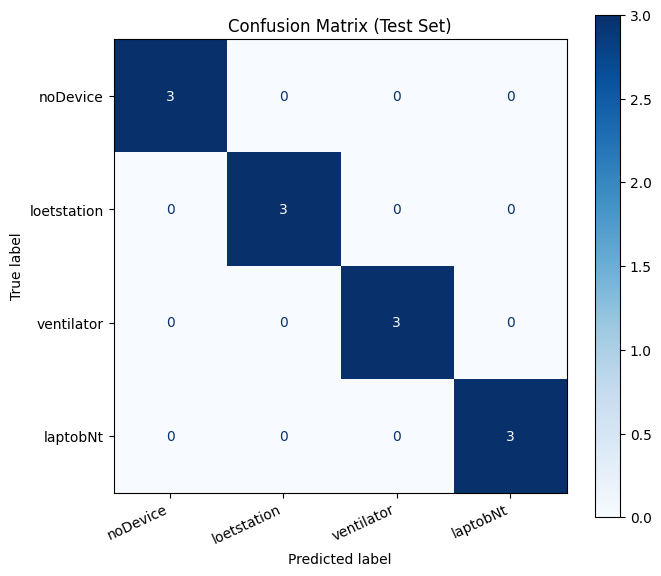

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# y_test und y_pred müssen schon existieren (aus deinem Training-Code)
# Beispiel:
# logits = model.predict(X_test_n, verbose=0)
# y_pred = np.argmax(logits, axis=1)

# ✅ Klassen-Namen passend zu deinen IDs (bitte ggf. Reihenfolge an dein Mapping anpassen)
class_names = ["noDevice", "loetstation", "ventilator", "laptobNt"]

cm = confusion_matrix(y_test, y_pred, labels=list(range(len(class_names))))

print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(
    y_test, y_pred, target_names=class_names, digits=4
))

# Plot (schön, groß, lesbar)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)

ax.set_title("Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np                 # Arrays/Mathe
import pandas as pd                # CSV laden
import tensorflow as tf            # TFLite Konverter

# mu, sigma = aus Training (norm_mean.txt / norm_std.txt)  # Norm-Parameter nutzen
X = pd.read_csv("x_values.csv").to_numpy(np.float32)       # Roh-Features laden

def rep_data_gen():
    n = min(len(X), 80)                 # max. 80 Samples
    for i in range(n):
        x = (X[i] - mu) / sigma         # wie im Training normieren
        yield [x.reshape(1, -1).astype(np.float32)]  # Batch-Form für TFLite

converter = tf.lite.TFLiteConverter.from_keras_model(model)  # Keras → TFLite
converter.optimizations = [tf.lite.Optimize.DEFAULT]          # Quantisierung aktivieren
converter.representative_dataset = rep_data_gen               # Kalibrier-Daten

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]  # INT8 Ops

converter.inference_input_type = tf.float32   # Input bleibt float
converter.inference_output_type = tf.float32  # Output bleibt float

tflite_int8_floatio = converter.convert()     # Modell konvertieren
open("model_int8_floatio.tflite", "wb").write(tflite_int8_floatio)  # Datei speichern

print("✅ model_int8_floatio.tflite:", len(tflite_int8_floatio), "bytes")  # Größe anzeigen


Saved artifact at '/tmp/tmpqbrswdsg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140310746428240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140310746420176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140310746423824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140310746421328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140310746416912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140310746431312: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ model_int8_floatio.tflite: 3648 bytes


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
import tensorflow as tf
inter = tf.lite.Interpreter(model_path="model_int8_floatio.tflite")
inter.allocate_tensors()
print("IN:", inter.get_input_details()[0]["dtype"])
print("OUT:", inter.get_output_details()[0]["dtype"])


IN: <class 'numpy.float32'>
OUT: <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
